In [1]:
# استيراد مكتبة files من google.colab لرفع الملفات من جهاز المستخدم إلى بيئة Colab
from google.colab import files

# فتح واجهة رفع الملفات ليقوم المستخدم باختيار ملف لتحميله إلى البيئة
# هذا مفيد لرفع بيانات أو نماذج جاهزة لاستخدامها لاحقًا
uploaded = files.upload()  # الكود ينتظر اختيار الملفات من الجهاز

Saving kaggle.json to kaggle.json


In [2]:
# إنشاء مجلد مخفي باسم .kaggle في المجلد الرئيسي لتخزين ملف إعدادات Kaggle
!mkdir -p ~/.kaggle

# نسخ ملف kaggle.json الذي يحتوي على مفتاح API الخاص بحساب Kaggle إلى المجلد الذي أنشأناه
!cp kaggle.json ~/.kaggle/

# تغيير أذونات الملف بحيث يكون مقروء فقط من قبل المستخدم الحالي لحماية مفتاح API
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# تثبيت مكتبة Kaggle الرسمية للتعامل مع واجهة برمجة التطبيقات الخاصة بموقع Kaggle
# الخيار -q يعني quiet أي تثبيت هادئ بدون إظهار تفاصيل كبيرة أثناء التثبيت
!pip -q install kaggle

In [4]:
# تحميل ملفات مسابقة Digit Recognizer من موقع Kaggle باستخدام API
# الخيار -c يحدد اسم المسابقة digit-recognizer
!kaggle competitions download -c digit-recognizer

# فك ضغط الملف الذي تم تحميله digit-recognizer.zip
# الخيار -o يعني overwrite أي استبدال الملفات إذا كانت موجودة مسبقاً
!unzip -o digit-recognizer.zip

# عرض جميع الملفات الموجودة في المجلد الحالي بالتفاصيل مثل الحجم وتاريخ التعديل
!ls -la

  0% 0.00/15.3M [00:00<?, ?B/s]
100% 15.3M/15.3M [00:00<00:00, 233MB/s]
Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
total 140840
drwxr-xr-x 1 root root     4096 Mar  1 01:35 .
drwxr-xr-x 1 root root     4096 Mar  1 01:34 ..
drwxr-xr-x 4 root root     4096 Feb  6 14:31 .config
-rw-r--r-- 1 root root 16054568 Dec 11  2019 digit-recognizer.zip
-rw-r--r-- 1 root root       68 Mar  1 01:35 kaggle.json
drwxr-xr-x 1 root root     4096 Feb  6 14:31 sample_data
-rw-r--r-- 1 root root   240909 Dec 11  2019 sample_submission.csv
-rw-r--r-- 1 root root 51118296 Dec 11  2019 test.csv
-rw-r--r-- 1 root root 76775041 Dec 11  2019 train.csv


In [5]:
import pandas as pd
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (42000, 785)
Test shape: (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


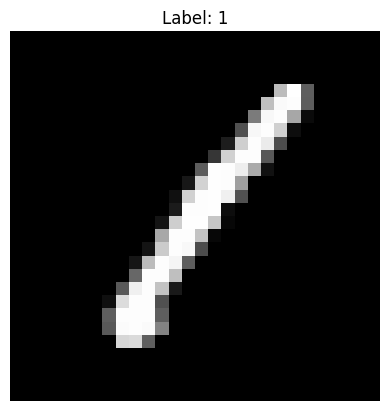

In [6]:
# استيراد مكتبة numpy للتعامل مع المصفوفات الرقمية والعمليات الحسابية
import numpy as np
# استيراد مكتبة matplotlib لرسم الصور والرسوم البيانية
import matplotlib.pyplot as plt

# اخذ قيمة التسمية الصحيحة للرقم في الصف الاول من مجموعة التدريب
label = train.loc[0, "label"]

# اخذ قيم البكسلات للصف الاول بدون عمود التسمية وتحويلها لمصفوفة
pixels = train.loc[0, train.columns != "label"].values

# اعادة تشكيل المصفوفة الى شكل 28 صف في 28 عمود لعرض الصورة بشكل صحيح
Image = pixels.reshape(28, 28)

# عرض الصورة بالالوان الرمادية لاظهار الرقم بوضوح
plt.imshow(Image, cmap="gray")

# وضع عنوان للصورة يوضح الرقم الصحيح للصف الاول
plt.title(f"Label: {label}")

# اخفاء محاور الرسم لاظهار الصورة بشكل نظيف
plt.axis("off")

# عرض الصورة فعليا في بيئة العمل
plt.show()

In [7]:
# استيراد دالة train_test_split لتقسيم البيانات الى تدريب و اختبار
from sklearn.model_selection import train_test_split

# استخراج ميزات التدريب وتحويلها من DataFrame الى مصفوفة float32 للتوافق مع الشبكات العصبية
x = train.drop("label", axis=1).to_numpy().astype("float32")

# استخراج التسميات وتحويلها الى مصفوفة int64 لاستخدامها في التدريب
y = train["label"].to_numpy().astype("int64")

# تحويل بيانات الاختبار الى مصفوفة float32 لتصبح جاهزة للمعالجة
x_test = test.to_numpy().astype("float32")

# تطبيع قيم الصور بقسمة كل البكسلات على 255 لجعل القيم بين صفر وواحد
x /= 255.0
x_test /= 255.0

# اعادة تشكيل مصفوفة التدريب لتصبح متوافقة مع مدخلات الشبكة العصبية (عدد عينات × 28 × 28 × 1)
x = x.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# تقسيم البيانات الى مجموعة تدريب و مجموعة تحقق بحيث يكون 80٪ تدريب و20٪ تحقق
# stratify=y لضمان توزيع التسميات بشكل متساوي في المجموعتين
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# طباعة احجام المجموعات بعد التقسيم للتأكد من صحة العملية
print("x_train:", x_train.shape, "x_val:", x_val.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape)

x_train: (33600, 28, 28, 1) x_val: (8400, 28, 28, 1)
y_train: (33600,) y_val: (8400,)


In [8]:
# استيراد مكتبة tensorflow لبناء الشبكات العصبية
import tensorflow as tf

# استيراد الطبقات والنماذج من keras لتصميم الشبكة
from tensorflow.keras import layers, models

# انشاء طبقات augmentation للتعديل على الصور اثناء التدريب لزيادة تنوع البيانات
augment = tf.keras.Sequential([
    # تدوير الصور بشكل عشوائي بنسبة 8 بالمئة لتقليل overfitting
    layers.RandomRotation(0.08),
    # ترجمة الصور افقيا وعموديا بنسبة 8 بالمئة لمحاكاة اختلافات الكتابة اليدوية
    layers.RandomTranslation(0.08, 0.08),
    # تكبير وتصغير الصور بنسبة 8 بالمئة لزيادة تنوع العينات
    layers.RandomZoom(0.08),
])

# تعريف نموذج الشبكة العصبية التتابعية CNN
model = models.Sequential([
    # تحديد شكل المدخلات ليكون صورة 28x28 بعمق قناة واحد
    layers.Input(shape=(28, 28, 1)),
    # اضافة طبقات الaugmentation لمعالجة الصور اثناء التدريب
    augment,

    # اول طبقة Conv2D مع 32 فلتر وpadding same للحفاظ على الابعاد
    layers.Conv2D(32, 3, padding="same"),
    # تطبيع الطبقة لزيادة استقرار التدريب
    layers.BatchNormalization(),
    # تفعيل الطبقة باستخدام ReLU لتقديم غير خطية للنموذج
    layers.Activation("relu"),
    # تصغير الابعاد باستخدام MaxPooling لتقليل حجم الصورة
    layers.MaxPooling2D(),

    # طبقة Conv2D ثانية مع 64 فلتر وتطبيع وتفعيل
    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    # طبقة Conv2D ثالثة مع 128 فلتر وتطبيع وتفعيل
    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    # تحويل كل الخرائط الى متجه واحد باستخدام GlobalAveragePooling
    layers.GlobalAveragePooling2D(),
    # تقليل overfitting باستخدام Dropout بنسبة 30 بالمئة
    layers.Dropout(0.3),

    # الطبقة الاخيرة Dense بعدد 10 وحدات لتصنيف الارقام من صفر الى 9
    layers.Dense(10, activation="softmax"),
])

# تجميع النموذج باستخدام Adam optimizer و categorical crossentropy و metric الدقة
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# عرض ملخص الشبكة لاظهار الطبقات وعدد المتغيرات
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,858 (370.54 KB)

 Trainable params: 94,410 (368.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# استيراد مكتبة re لامور التعبيرات النمطية هنا غير مستخدمة مباشرة لكنها جاهزة
from re import VERBOSE
# استيراد الCallbacks للتحكم في التدريب وتقليل overfitting وضبط التعلم
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# انشاء قائمة callbacks لتطبيقها اثناء التدريب
callbacks = [
    # ايقاف التدريب مبكرا اذا لم تتحسن دقة التحقق لعدد معين من الحلقات مع استعادة افضل وزن
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    # تقليل معدل التعلم تلقائيا اذا لم يتحسن فقد القيمة لفترة محددة لضبط التدرج
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

# بدء تدريب النموذج باستخدام بيانات التدريب والتحقق مع استخدام ال callbacks
history = model.fit(
    x_train, y_train,                       # بيانات التدريب والتسميات
    validation_data=(x_val, y_val),         # بيانات التحقق لتقييم النموذج بعد كل epoch
    epochs=20,                               # عدد الحلقات للتدريب الكلي
    callbacks=callbacks,                     # تطبيق ال callbacks خلال التدريب
    batch_size=128,                          # عدد العينات في كل دفعة تدريب
    verbose=1                                 # اظهار تقدم التدريب في كل حلقة
)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6261 - loss: 1.2482 - val_accuracy: 0.0968 - val_loss: 13.1215 - learning_rate: 0.0010
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9245 - loss: 0.3051 - val_accuracy: 0.2761 - val_loss: 4.9537 - learning_rate: 0.0010
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9453 - loss: 0.2093 - val_accuracy: 0.8377 - val_loss: 0.5137 - learning_rate: 0.0010
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9511 - loss: 0.1758 - val_accuracy: 0.4799 - val_loss: 2.3532 - learning_rate: 0.0010
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9572 - loss: 0.1498 - val_accuracy: 0.9314 - val_loss: 0.2061 - learning_rate: 0.0010
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9620 - loss: 0.1375 - val_accuracy: 0.4387 - val_loss: 2.3037 - learning_rate: 0.0010
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9614 - loss: 

/tmp/ipython-input-323/2857498115.py:2: DeprecationWarning: module 'sre_compile' is deprecated
  from sre_compile import dis


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       827
           1       0.99      0.99      0.99       937
           2       0.98      0.98      0.98       835
           3       0.96      0.99      0.98       870
           4       0.98      0.99      0.98       814
           5       0.96      0.98      0.97       759
           6       1.00      0.98      0.99       827
           7       0.98      0.98      0.98       880
           8       0.97      0.96      0.97       813
           9       0.99      0.96      0.98       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



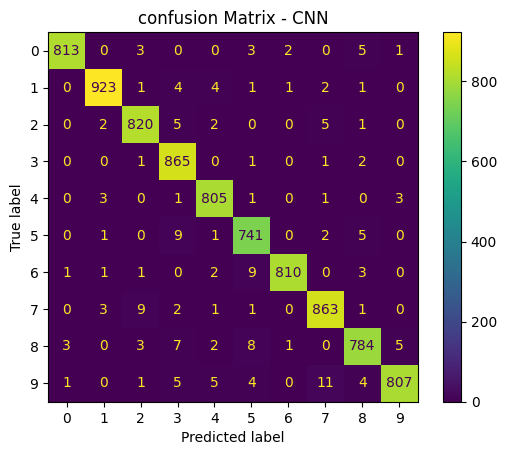

In [10]:
# استيراد dis من sre_compile هنا غير مستخدم مباشرة لكنه موجود للامثلة
from sre_compile import dis
# استيراد الدوال الخاصة بحساب مصفوفة الالتباس وعرضها والتقرير التفصيلي
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
# استيراد matplotlib للرسم البياني وعرض الصور
import matplotlib.pyplot as plt

# استخدام النموذج للتنبؤ على بيانات التحقق وتحويل المخرجات من احتمالات الى الفئة الأعلى
y_val_pred = np.argmax(model.predict(x_val), axis=-1)

# طباعة التقرير التفصيلي للاداء يشمل precision و recall و f1-score لكل رقم
print(classification_report(y_val, y_val_pred))

# حساب مصفوفة الالتباس لمقارنة القيم الحقيقية بالقيم المتوقعة
cm = confusion_matrix(y_val, y_val_pred)
# تحضير مصفوفة الالتباس للعرض بشكل جميل
disp = ConfusionMatrixDisplay(cm)
# عرض مصفوفة الالتباس مع ضبط القيم لتظهر كأعداد صحيحة
disp.plot(values_format="d")
# اضافة عنوان للرسم البياني
plt.title("confusion Matrix - CNN")
# اظهار الرسم البياني النهائي لمصفوفة الالتباس
plt.show()

In [11]:
# استخدام النموذج للتنبؤ على بيانات الاختبار وتحويل احتمالات المخرجات الى الفئة الأعلى
test_pred = np.argmax(model.predict(x_test), axis=-1)

# انشاء جدول بيانات جديد لتجهيز الملف النهائي للمسابقة او للتسليم
# العمود الاول ImageId يحدد ترتيب الصور من 1 الى عدد الصور
# العمود الثاني Label يحتوي على التنبؤات التي قام بها النموذج لكل صورة
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_pred)+1),
    "Label": test_pred
})

# حفظ الجدول كملف CSV باسم AI.csv بدون تضمين الفهرس
submission.to_csv("AI.csv", index=False)
# عرض أول خمس صفوف من الملف للتأكد من صحة البيانات
submission.head()

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [12]:
# استدعاء مكتبة files من Colab للسماح بتحميل الملفات من البيئة السحابية الى جهازك المحلي
from google.colab import files

# تحميل الملف AI.csv الذي يحتوي على نتائج التنبؤات النهائية للنموذج
# عند تنفيذ هذا السطر سيظهر رابط لتحميل الملف مباشرة على الكمبيوتر
files.download("AI.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# حفظ النموذج العصبي المدرب بعد اكتمال التدريب والتقييم
# هذا يسمح لنا بإعادة تحميل النموذج لاحقا دون الحاجة لاعادة التدريب
# الاسم digit_model.keras هو اسم الملف الذي سيتم انشاءه في البيئة الحالية
model.save("digit_model.keras")

In [14]:
# تثبيت مكتبة gradio وهي المكتبة التي تستخدم لبناء واجهات المستخدم التفاعلية للنماذج
# الخيار -q يجعل التثبيت هادئ بدون اظهار كل الرسائل في الconsole
# هذا يسمح لنا بانشاء واجهة تفاعلية يستطيع الطالب او المستخدم التجربة عليها مباشرة
!pip -q install gradio

In [15]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2
import plotly.graph_objects as go

# 1️⃣ تحميل المحرك العصبي (Model Engine)
try:
    model = tf.keras.models.load_model("digit_model.keras")
except:
    print("❌ Critical Error: Neural Engine File Not Found")

# 2️⃣ البروتوكولات الذكية (Logic & Safety)
CONF_THRESHOLD = 0.85
INK_LIMITS = (0.01, 0.35)

def analyze_structure(img28):
    """تحليل هيكلي لمنع الصور العشوائية"""
    ink_density = np.mean(img28 > 0.2)
    if not (INK_LIMITS[0] < ink_density < INK_LIMITS[1]):
        return False, "إشارة غير منتظمة (ليست بنية رقم)"

    binary = (img28 > 0.5).astype(np.uint8)
    num_labels, _ = cv2.connectedComponents(binary)
    if num_labels - 1 > 3:
        return False, "تداخل عالي التردد (ضجيج)"
    return True, "تم التحقق"

def preprocess_engine(img_input):
    if img_input is None: return None
    # معالجة المدخلات من كلا المصدرين
    raw_img = np.array(img_input['composite'] if isinstance(img_input, dict) else img_input)

    if raw_img.ndim == 3:
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_RGBA2GRAY if raw_img.shape[2]==4 else cv2.COLOR_RGB2GRAY)

    _, bin_img = cv2.threshold(raw_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    resized = cv2.resize(bin_img, (28, 28))
    img_float = resized.astype("float32")

    if img_float.mean() > 127: img_float = 255 - img_float
    return img_float / 255.0

def generate_cyber_plot(probs):
    """إنشاء رسم بياني مستقبلي"""
    fig = go.Figure(go.Bar(
        x=[str(i) for i in range(10)], y=probs,
        marker=dict(
            color=probs,
            colorscale=[[0, '#1e293b'], [0.5, '#6366f1'], [1, '#00f2fe']],
            line=dict(color='#00f2fe', width=0.5)
        ),
    ))
    fig.update_layout(
        plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)',
        font=dict(color="#00f2fe", family="Courier New"),
        height=250, margin=dict(t=20, b=20, l=10, r=10),
        yaxis=dict(showgrid=False, showticklabels=False),
        xaxis=dict(showgrid=False)
    )
    return fig

def neural_inference(img):
    processed = preprocess_engine(img)
    if processed is None or np.sum(processed) < 1:
        return "📡 [SYSTEM IDLE]", None, {}

    is_valid, reason = analyze_structure(processed)
    if not is_valid:
        return f"🚫 [ACCESS DENIED]: {reason}", None, {}

    tensor = processed.reshape(1, 28, 28, 1)
    probs = model.predict(tensor, verbose=0)[0]
    conf = float(np.max(probs))

    if conf < CONF_THRESHOLD:
        return f"⚠️ [SIGNAL WEAK]: {conf:.1%}", None, {}

    pred = int(np.argmax(probs))
    return f"✨ [RESULT]: DIGIT {pred}", generate_cyber_plot(probs), {str(i): float(probs[i]) for i in range(10)}

# 🎨 CSS: THE CYBERNETIC DASHBOARD
cyber_css = """
@import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&display=swap');
.gradio-container { background: #050505 !important; font-family: 'Share Tech Mono', monospace !important; }
.main-frame {
    border: 2px solid #00f2fe;
    box-shadow: 0 0 20px #00f2fe33;
    border-radius: 15px;
    background: rgba(0,0,0,0.8);
    padding: 40px !important;
}
.cyber-title {
    text-align: center;
    color: #00f2fe;
    text-transform: uppercase;
    letter-spacing: 5px;
    margin-bottom: 30px;
    text-shadow: 0 0 10px #00f2fe;
}
.scan-btn {
    background: transparent !important;
    border: 2px solid #00f2fe !important;
    color: #00f2fe !important;
    transition: all 0.4s !important;
}
.scan-btn:hover {
    background: #00f2fe !important;
    color: black !important;
    box-shadow: 0 0 30px #00f2fe;
}
.res-box textarea {
    background: black !important;
    color: #00f2fe !important;
    border: 1px dashed #00f2fe !important;
    font-size: 20px !important;
    text-align: center !important;
}
"""

with gr.Blocks(css=cyber_css) as demo:
    with gr.Column(elem_classes="main-frame"):
        gr.Markdown("# 🛸 NEURAL SCANNER v3.0", elem_classes="cyber-title")

        with gr.Row():
            # LEFT: SENSOR INPUT
            with gr.Column(scale=1):
                with gr.Tabs():
                    with gr.TabItem("💠 DIGITAL PAD"):
                        sketch = gr.Sketchpad(label="Input Matrix", type="numpy", layers=False)
                    with gr.TabItem("💾 DATA FEED"):
                        file = gr.Image(label="File Stream", type="numpy")

                with gr.Row():
                    clear_btn = gr.Button("CLEAR BUFFER", variant="stop")
                    scan_btn = gr.Button("INITIALIZE SCAN", variant="primary", elem_classes="scan-btn")

            # RIGHT: ANALYTICS
            with gr.Column(scale=1):
                out_txt = gr.Textbox(label="SYSTEM STATUS", elem_classes="res-box")
                out_plot = gr.Plot(label="PROBABILITY WAVES")
                with gr.Accordion("RAW NEURAL WEIGHTS", open=False):
                    out_lbl = gr.Label(label="Neuron Distribution")

        gr.Markdown("<p style='text-align:center; color:#444; margin-top:20px;'>CORE PROTOCOL: HANDWRITTEN DIGITS ONLY | SECURITY LEVEL: HIGH</p>")

    # ACTIONS
    scan_btn.click(fn=neural_inference, inputs=sketch, outputs=[out_txt, out_plot, out_lbl])
    scan_btn.click(fn=neural_inference, inputs=file, outputs=[out_txt, out_plot, out_lbl])
    clear_btn.click(fn=lambda: (None, None, "", None, {}), outputs=[sketch, file, out_txt, out_plot, out_lbl])

demo.launch()

/tmp/ipython-input-323/3607344670.py:121: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=cyber_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://618347452d22219b49.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
